<a href="https://colab.research.google.com/github/Anothaatype/PCVK-Semester-5/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
#Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im
import torch
import torch.nn as nn

## **Convolution**

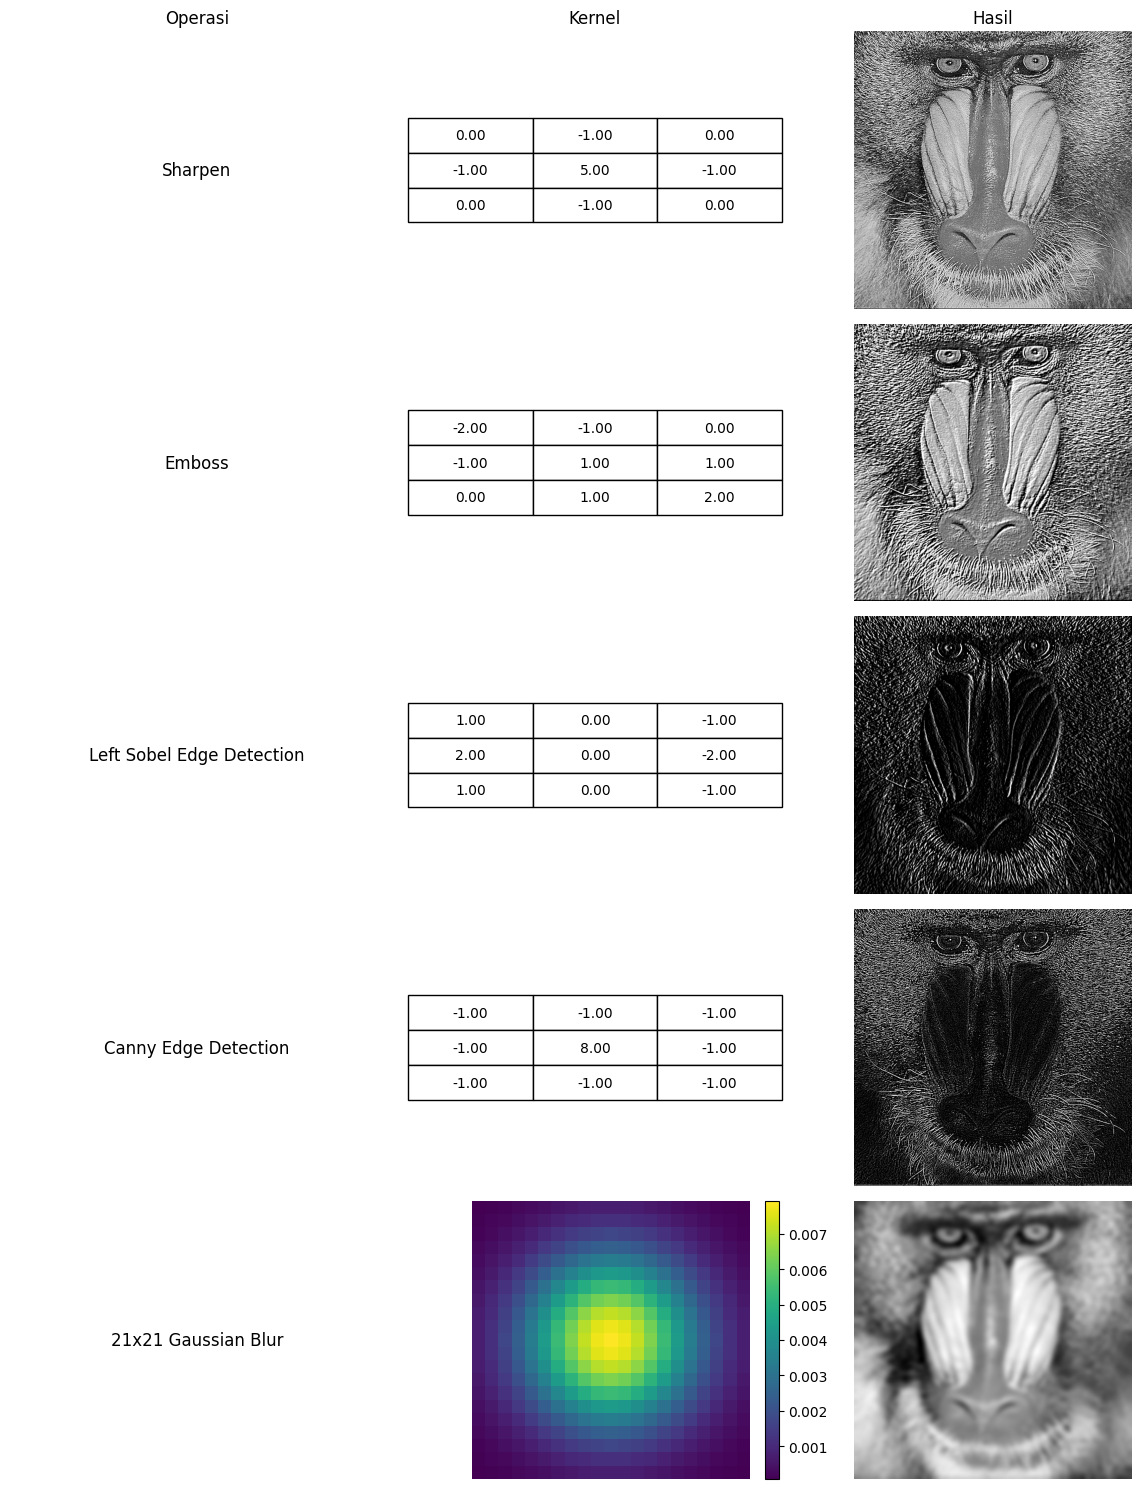

In [18]:
# -------------------------
# Helper: convolution wrapper
# -------------------------
def convolution2d(img, kernel):
    # ensure kernel is float32
    k = np.array(kernel, dtype=np.float32)
    return cv.filter2D(img, -1, k)

# -------------------------
# Helper: pretty kernel plot
# -------------------------
def plot_kernel(ax, kernel):
    k = np.array(kernel, dtype=np.float32)
    ax.axis("off")
    max_dim = max(k.shape)
    if k.size <= 25:  # small kernel -> show as table of values
        # format numbers
        cell_text = [[f"{val:.2f}" for val in row] for row in k]
        table = ax.table(cellText=cell_text, loc="center", cellLoc="center")
        table.scale(1, 1.5)
    else:  # large kernel -> show heatmap
        im = ax.imshow(k, cmap="viridis", interpolation="nearest")
        ax.set_xticks([])
        ax.set_yticks([])
        # add colorbar
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# -------------------------
# Load image (grayscale)
# -------------------------
img_path = '/content/drive/MyDrive/PCVK_MM/Images-Polinema/mandrill.tiff'
img = cv.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Cannot find image at: {img_path}")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# -------------------------
# Define kernels
# -------------------------
kernelS = np.array([[0, -1,  0],
                    [-1, 5, -1],
                    [0, -1,  0]], dtype=np.float32)

kernelE = np.array([[-2, -1, 0],
                    [-1,  1, 1],
                    [0,   1, 2]], dtype=np.float32)

kernelLSED = np.array([[1, 0, -1],
                       [2, 0, -2],
                       [1, 0, -1]], dtype=np.float32)

kernelCED = np.array([[-1, -1, -1],
                      [-1,  8, -1],
                      [-1, -1, -1]], dtype=np.float32)

kernel_size = 21
sigma = math.sqrt(kernel_size)
g_col = cv.getGaussianKernel(kernel_size, sigma).astype(np.float32)   # column vector
gauss_kernel = (g_col @ g_col.T).astype(np.float32)                  # 2D 21x21 kernel

# -------------------------
# Apply filters
# -------------------------
sharpened     = convolution2d(img_gray, kernelS)
embossed      = convolution2d(img_gray, kernelE)
sobel_left    = convolution2d(img_gray, kernelLSED)
canny_like    = convolution2d(img_gray, kernelCED)
gaussian_blur = convolution2d(img_gray, gauss_kernel)

# -------------------------
# Prepare table data
# -------------------------
titles = ["Sharpen", "Emboss", "Left Sobel Edge Detection",
          "Canny Edge Detection", "21x21 Gaussian Blur"]

kernels = [kernelS, kernelE, kernelLSED, kernelCED, gauss_kernel]
results = [sharpened, embossed, sobel_left, canny_like, gaussian_blur]

# -------------------------
# Plot Operasi | Kernel | Hasil
# -------------------------
n = len(results)
fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(12, 3*n))

for i in range(n):
    # Column 0: Operation name
    ax0 = axes[i, 0]
    ax0.axis("off")
    ax0.text(0.5, 0.5, titles[i], fontsize=12, ha="center", va="center")
    if i == 0:
        ax0.set_title("Operasi")

    # Column 1: Kernel (table or heatmap)
    ax1 = axes[i, 1]
    plot_kernel(ax1, kernels[i])
    if i == 0:
        ax1.set_title("Kernel")

    # Column 2: Result image
    ax2 = axes[i, 2]
    ax2.imshow(results[i], cmap="gray")
    ax2.axis("off")
    if i == 0:
        ax2.set_title("Hasil")

plt.tight_layout()
plt.show()

## **Filter Library and Modern Filter**

### **Experiment 1 - Original, Gaussian Blur, Sharpened, Canny Edge Detection**

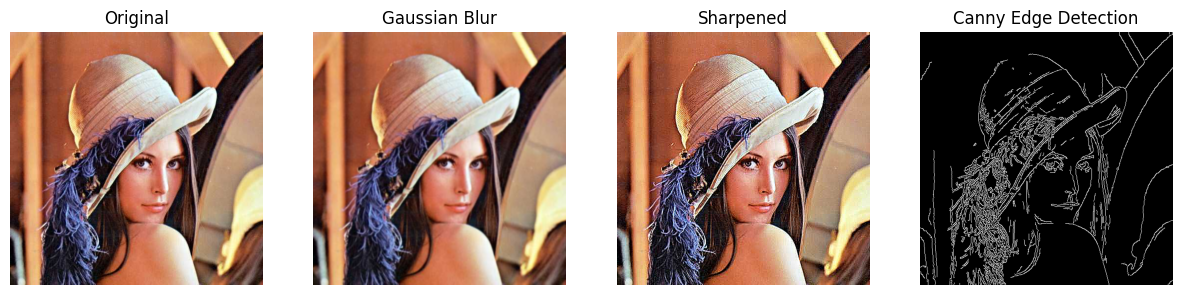

In [19]:
# Function to display images side by side
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)

        # Check if image is grayscale or color
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))

        plt.title(title)
        plt.axis("off")

    plt.show()


# Load image
img = cv.imread("/content/drive/MyDrive/PCVK_MM/Images-Polinema/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Apply Gaussian Blur
blur = cv.GaussianBlur(img, (7, 7), 1)

# Apply Canny Edge Detection
edges = cv.Canny(img_gray, 100, 200)

# Apply Sharpening filter
sharpen_kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

# Show results side by side
show_side_by_side(
    [img, blur, sharpened, edges],
    ["Original", "Gaussian Blur", "Sharpened", "Canny Edge Detection"]
)

### **Experiment 2 - Bilateral and Guided Filter**

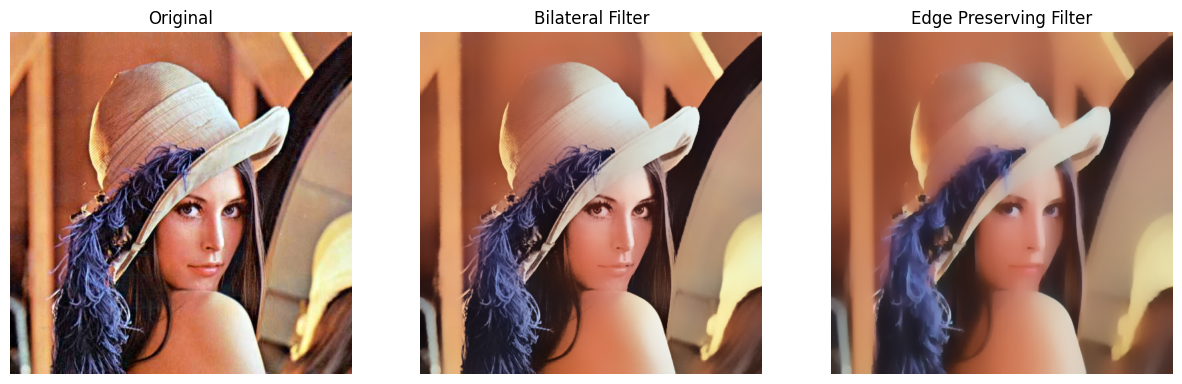

In [20]:
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, d=50, sigmaColor=100, sigmaSpace=100)

# Edge Preserving Filter (alternative to Guided Filter)
edge_preserve = cv.edgePreservingFilter(
    img, flags=1, sigma_s=100, sigma_r=0.9
)

# Show results side by side
show_side_by_side(
    [img, bilateral, edge_preserve],
    ["Original", "Bilateral Filter", "Edge Preserving Filter"]
)

Conclusion : The application of the Bilateral Filter demonstrates that it can smooth out noise effectively while still maintaining sharp edges. Compared to Gaussian Blur, the Bilateral Filter is able to retain important structural details, making it highly useful in scenarios where edge preservation is critical, such as medical imaging or object recognition tasks.

### **Experiment 3 - Convolution**

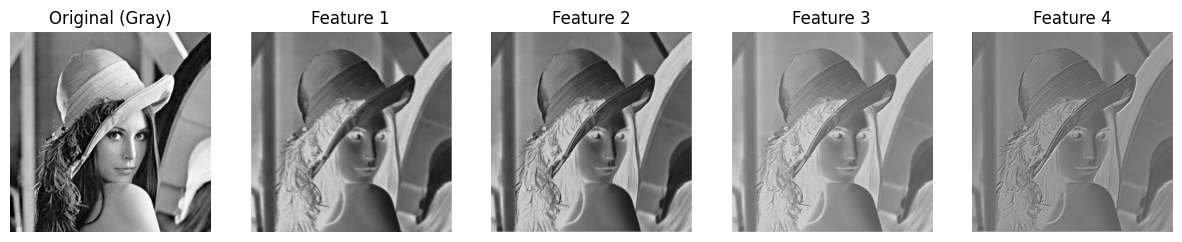

In [21]:
# Simple CNN with one convolution layer
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)


# Initialize model
model = SimpleCNN()

# Convert grayscale image to tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Extract CNN feature maps (no gradient needed)
with torch.no_grad():
    features = model(img_tensor)

# Convert feature maps to numpy for visualization
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]

# Visualize results
show_side_by_side(
    [img_gray] + feature_maps,
    ["Original (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))]
)

### **Experiment 4 - Beauty Filter, Old Vintage Filter**

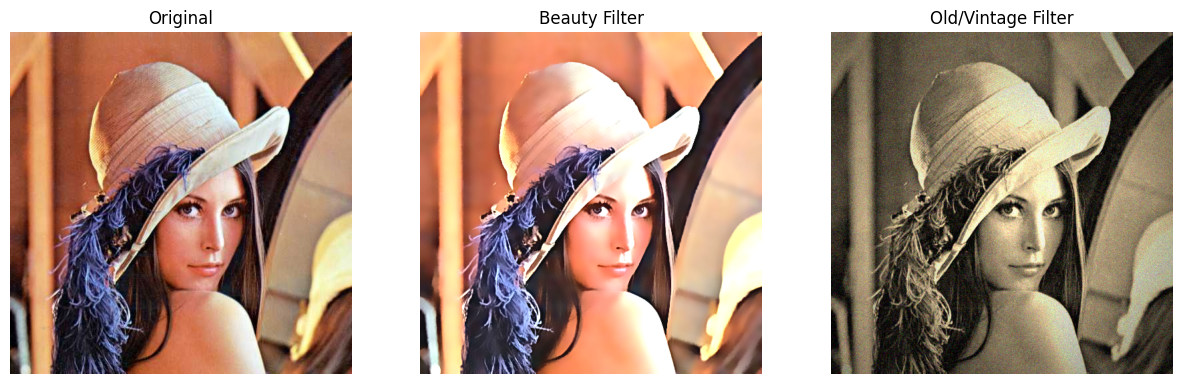

In [22]:
# =========================
# 1. Beauty Filter
# =========================
def apply_beauty_filter(img, d=15, sigma_color=75, sigma_space=75, alpha=1.2, beta=15):
    # Step 1: Smooth skin using bilateral filter
    smooth = cv.bilateralFilter(img, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)

    # Step 2: Unsharp masking (enhance edges like eyes/lips)
    gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
    sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

    # Step 3: Brightness & Contrast adjustment
    beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

    return beauty


# =========================
# 2. Old/Vintage Filter
# =========================
def apply_vintage_filter(img):
    # Step 1: Sepia tone
    sepia_kernel = np.array([
        [0.272, 0.534, 0.131],
        [0.349, 0.686, 0.168],
        [0.393, 0.769, 0.189]
    ])
    sepia = cv.transform(img, sepia_kernel)
    sepia = np.clip(sepia, 0, 255).astype(np.uint8)

    # Step 2: Vignette effect
    rows, cols = img.shape[:2]
    kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
    kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
    kernel = kernel_y @ kernel_x.T
    mask = kernel / kernel.max()

    vignette = np.copy(sepia)
    for i in range(3):  # apply mask per channel
        vignette[:, :, i] = vignette[:, :, i] * mask

    # Step 3: Add noise/grain
    noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
    old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return old_img


# =========================
# Apply Filters
# =========================
beauty = apply_beauty_filter(img)
vintage = apply_vintage_filter(img)

# Show side by side
show_side_by_side(
    [img, beauty, vintage],
    ["Original", "Beauty Filter", "Old/Vintage Filter"]
)

### **Experiment 5 - Anime / Cartoon Filter**

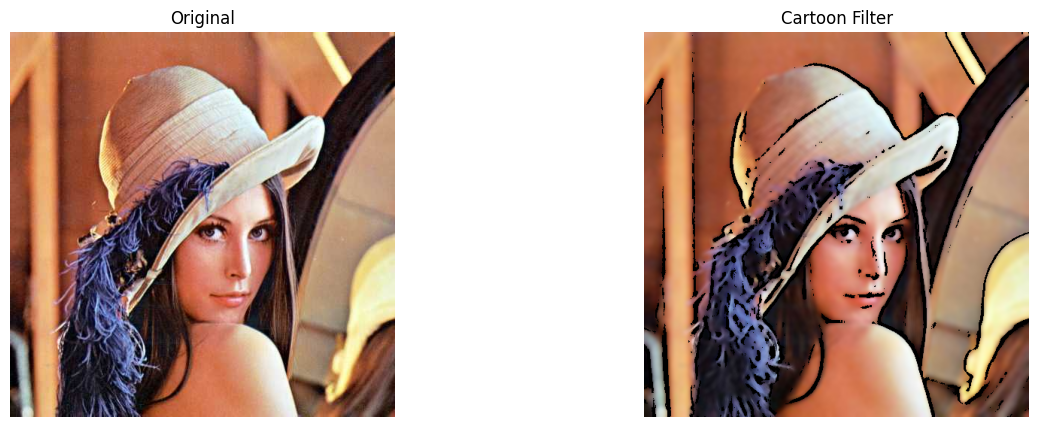

In [23]:
def apply_cartoon_filter(img, d=9, sigma_color=200, sigma_space=200):
    # Step 1: Edge detection (use median blur for smoother edges)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(
        gray_blur, 255,
        cv.ADAPTIVE_THRESH_MEAN_C,
        cv.THRESH_BINARY,
        blockSize=9,
        C=9
    )

    # Step 2: Bilateral filter for color smoothing
    color = cv.bilateralFilter(img, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)

    # Step 3: Combine edges with smoothed color
    cartoon = cv.bitwise_and(color, color, mask=edges)

    return cartoon


# =========================
# Apply Cartoon Filter
# =========================
cartoon = apply_cartoon_filter(img)

# Show comparison
show_side_by_side(
    [img, cartoon],
    ["Original", "Cartoon Filter"]
)

### **Experiment 6 - Night Filter**

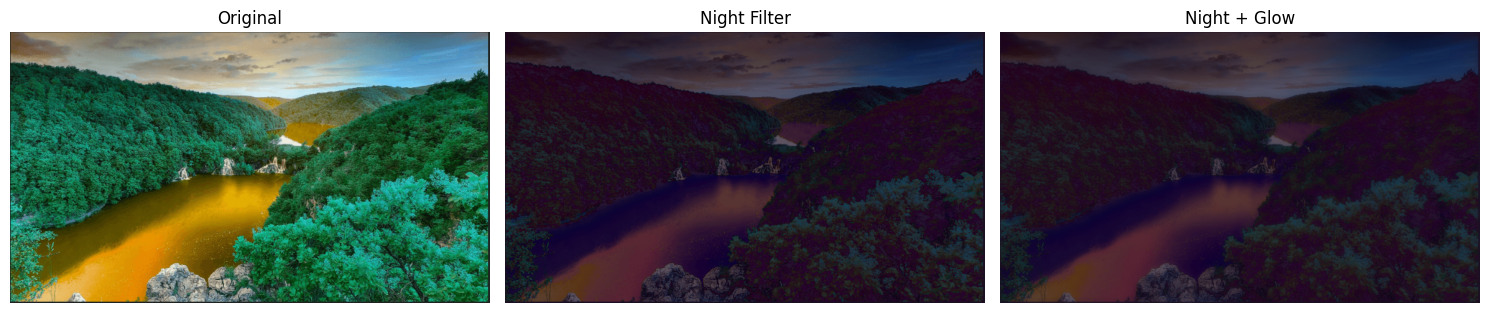

In [28]:
def apply_night_filter(img, alpha=0.6, beta=-40, blue_bias=(50, 0, 100), glow_kernel_size=15):
    night = cv.convertScaleAbs(img, alpha=alpha, beta=beta)
    blue_tint = np.full_like(night, blue_bias)
    night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)
    kernel = np.ones((glow_kernel_size, glow_kernel_size), np.float32) / 225
    glow = cv.filter2D(night, -1, kernel)
    night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)
    return night, night_glow

img = cv.imread('/content/drive/MyDrive/PCVK_MM/Images-Polinema/jungle.png')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

# Apply filter
night, night_glow = apply_night_filter(img)

# Show results side by side
titles = ["Original", "Night Filter", "Night + Glow"]
images = [img, night, night_glow]

plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

### **Experiment 7 - Morning and Fog Filters**

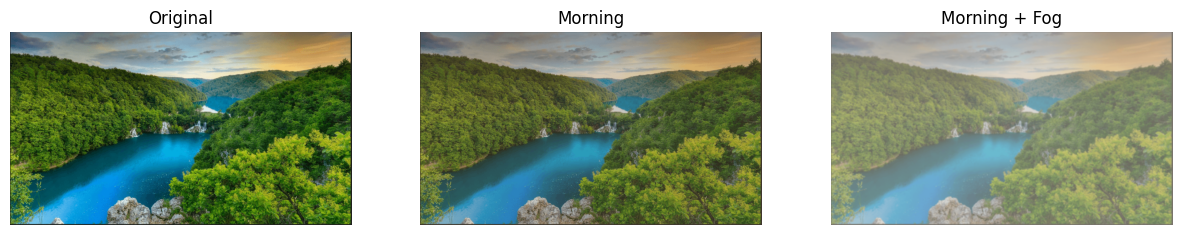

In [29]:
def apply_morning_fog_filter(img, alpha=0.9, beta=20, warm_tone=(40, 70, 120)):
    # Step 1: Reduce contrast & brighten
    soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

    # Step 2: Add warm tone (orangish tint)
    warm_tint = np.full_like(soft, warm_tone)
    pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

    # Step 3: Add haze/fog with Gaussian blur kernel
    kernel = cv.getGaussianKernel(3, 3)
    kernel = kernel @ kernel.T  # Make it 2D
    kabut = cv.filter2D(pagi, -1, kernel)

    # Step 4: Add white overlay for more realistic fog
    white_layer = np.full_like(pagi, 255)
    kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

    return pagi, kabut


# =========================
# Apply Morning + Fog Filter
# =========================
pagi, kabut = apply_morning_fog_filter(img)

# Show comparison
show_side_by_side(
    [img, pagi, kabut],
    ["Original", "Morning", "Morning + Fog"]
)